In [1]:
# ============================================================
# SECTION 1: SETUP & DATA LOADING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Professional plot styling
plt.rcParams.update({
    'figure.figsize': (14, 7),
    'figure.dpi': 100,
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.fontsize': 11,
    'legend.frameon': False
})

# Custom color palette (Africa-themed)
COLORS = {
    'africa': '#E63946',
    'asia': '#457B9D',
    'europe': '#2A9D8F',
    'north_america': '#E9C46A',
    'south_america': '#F4A261',
    'oceania': '#264653',
    'world': '#6C757D',
    'ghana': '#006B3F',
    'nigeria': '#008751',
    'fossil': '#E76F51',
    'renewable': '#2A9D8F',
    'solar': '#F4A261',
    'wind': '#457B9D',
    'hydro': '#264653',
    'nuclear': '#9B59B6'
}

# Load data from Our World in Data GitHub
url = 'https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv'
df = pd.read_csv(url)

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Countries/Regions: {df['country'].nunique()}")
print(f"Year range: {df['year'].min()} - {df['year'].max()}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Quick data quality check
missing_pct = (df.isnull().sum() / len(df) * 100).describe()
print(f"\nMissing values summary:")
print(f"  Average column missingness: {missing_pct['mean']:.1f}%")
print(f"  Max column missingness: {missing_pct['max']:.1f}%")

Dataset loaded: 23,377 rows x 130 columns
Countries/Regions: 314
Year range: 1900 - 2025

Memory usage: 25.2 MB

Missing values summary:
  Average column missingness: 65.7%
  Max column missingness: 91.1%


In [2]:
african_countries = ['Algeria','Angola','Ghana','Egypt','Nigeria','Kenya','Morocco','South Africa','Tanzania','Uganda','Tunisia','Senegal','Cameroon','Zimbabwe','Zambia','Sudan','Mali','Niger','Mozambique','Ethiopia']

df_africa = df[(df['country'].isin(african_countries)) & (df['year'] >= 1990) & (df['year'] <= 2022)].copy()

print(df_africa.shape)
print(df_africa['country'].nunique())

(660, 130)
20


In [3]:
print(df.columns.tolist())

['country', 'year', 'iso_code', 'population', 'gdp', 'biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'biofuel_share_energy', 'carbon_intensity_elec', 'coal_cons_change_pct', 'coal_cons_change_twh', 'coal_cons_per_capita', 'coal_consumption', 'coal_elec_per_capita', 'coal_electricity', 'coal_prod_change_pct', 'coal_prod_change_twh', 'coal_prod_per_capita', 'coal_production', 'coal_share_elec', 'coal_share_energy', 'electricity_demand', 'electricity_demand_per_capita', 'electricity_generation', 'electricity_share_energy', 'energy_cons_change_pct', 'energy_cons_change_twh', 'energy_per_capita', 'energy_per_gdp', 'fossil_cons_change_pct', 'fossil_cons_change_twh', 'fossil_elec_per_capita', 'fossil_electricity', 'fossil_energy_per_capita', 'fossil_fuel_consumption', 'fossil_share_elec', 'fossil_share_energy', 'gas_cons_change_pct', 'gas_cons_change_twh', 'gas_consu

In [4]:
african_countries = ['Algeria','Angola','Ghana','Egypt','Nigeria','Kenya','Morocco','South Africa','Tanzania','Uganda','Tunisia','Senegal','Cameroon','Zimbabwe','Zambia','Sudan','Mali','Niger','Mozambique','Ethiopia']

df_africa = df[(df['country'].isin(african_countries)) & (df['year'] >= 1990) & (df['year'] <= 2022)].copy()

print(df_africa.shape)
print(df_africa['country'].nunique())


(660, 130)
20


In [5]:
# Drop columns with more than 70% missing
threshold = 0.7
cols_to_keep = df_africa.columns[df_africa.isnull().mean()< threshold]
df_clean = df_africa[cols_to_keep].copy()

print(df_clean.shape)
print(df_clean.columns.tolist())

(660, 75)
['country', 'year', 'iso_code', 'population', 'gdp', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'carbon_intensity_elec', 'coal_elec_per_capita', 'coal_electricity', 'coal_prod_change_pct', 'coal_prod_change_twh', 'coal_prod_per_capita', 'coal_production', 'coal_share_elec', 'electricity_demand', 'electricity_demand_per_capita', 'electricity_generation', 'energy_cons_change_pct', 'energy_cons_change_twh', 'energy_per_capita', 'energy_per_gdp', 'fossil_elec_per_capita', 'fossil_electricity', 'fossil_share_elec', 'gas_elec_per_capita', 'gas_electricity', 'gas_prod_change_pct', 'gas_prod_change_twh', 'gas_prod_per_capita', 'gas_production', 'gas_share_elec', 'greenhouse_gas_emissions', 'hydro_elec_per_capita', 'hydro_electricity', 'hydro_share_elec', 'low_carbon_elec_per_capita', 'low_carbon_electricity', 'low_carbon_share_elec', 'net_elec_imports', 'net_elec_imports_share_de

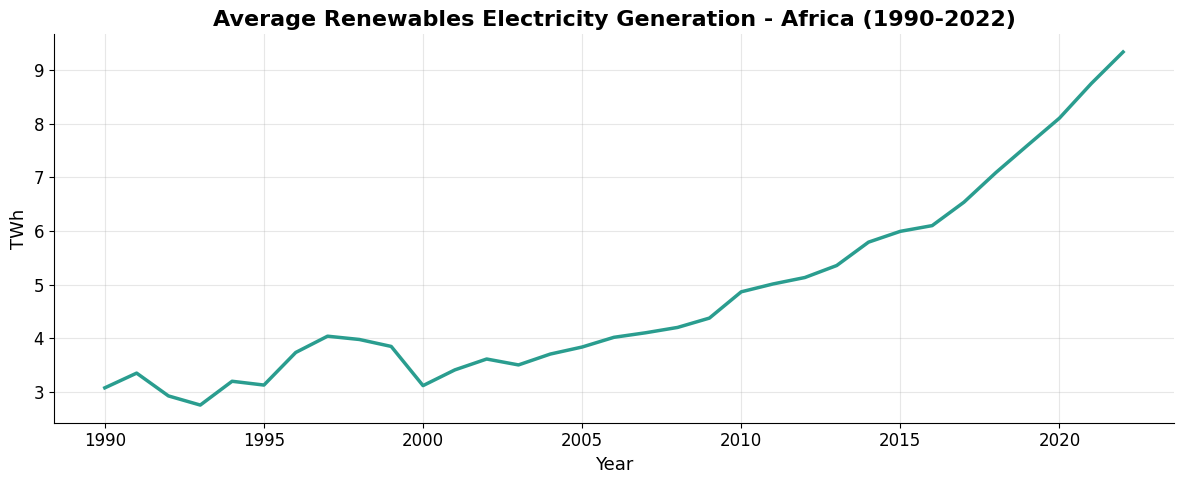

In [6]:
import matplotlib.pyplot as plt

renewables = df_clean.groupby('year')['renewables_electricity'].mean()

plt.figure(figsize=(12,5))
plt.plot(renewables.index, renewables.values, color='#2A9D8F', linewidth=2.5)
plt.title('Average Renewables Electricity Generation - Africa (1990-2022)')
plt.xlabel('Year')
plt.ylabel('TWh')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

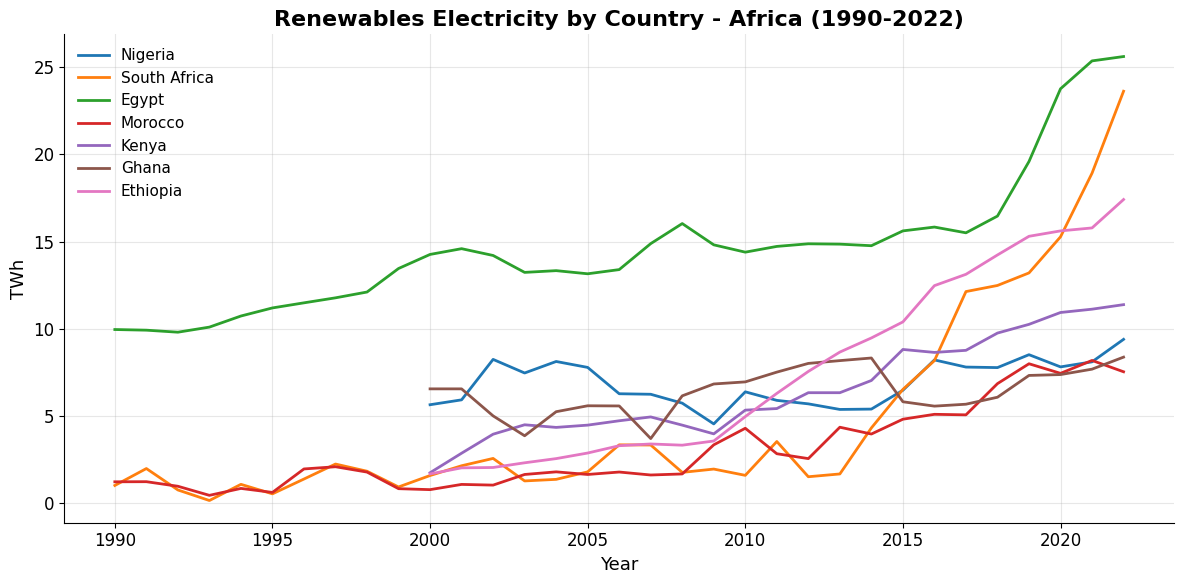

In [7]:
top_countries = ['Nigeria','South Africa','Egypt','Morocco','Kenya','Ghana','Ethiopia']

fig, ax = plt.subplots(figsize=(12,6))

for country in top_countries:
    data = df_clean[df_clean['country'] == country].groupby('year')['renewables_electricity'].mean()
    ax.plot(data.index, data.values, label=country, linewidth=2)

ax.set_title('Renewables Electricity by Country - Africa (1990-2022)')
ax.set_xlabel('Year')
ax.set_ylabel('TWh')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

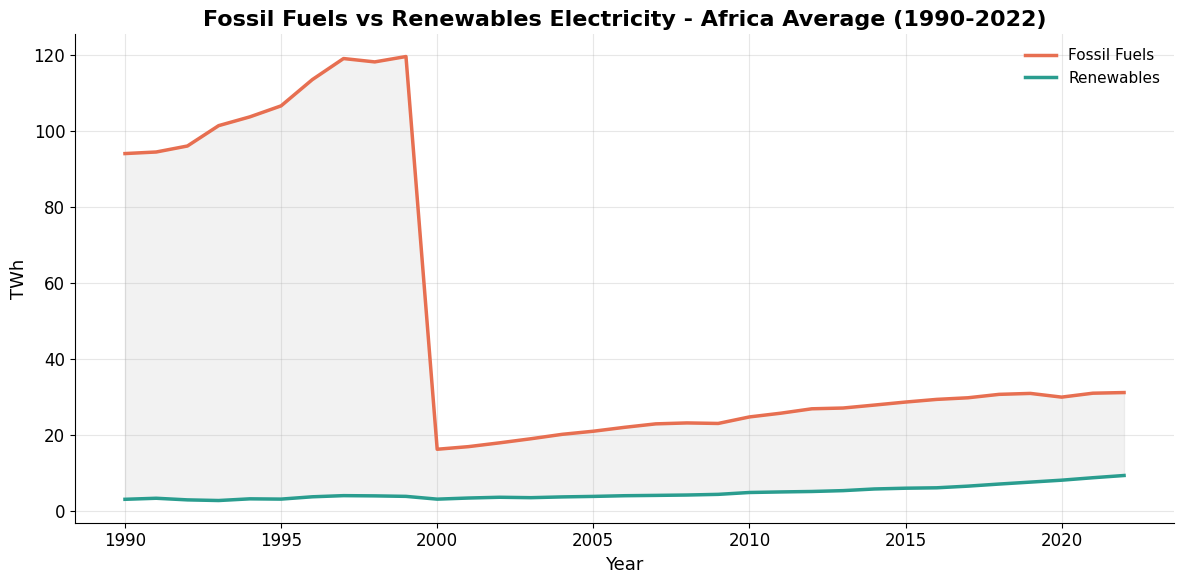

In [8]:
fossil_vs_renew = df_clean.groupby('year')[['fossil_electricity','renewables_electricity']].mean()

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(fossil_vs_renew.index, fossil_vs_renew['fossil_electricity'], color='#E76F51', linewidth=2.5, label='Fossil Fuels')
ax.plot(fossil_vs_renew.index, fossil_vs_renew['renewables_electricity'], color='#2A9D8F', linewidth=2.5, label='Renewables')

ax.fill_between(fossil_vs_renew.index, fossil_vs_renew['fossil_electricity'], fossil_vs_renew['renewables_electricity'], alpha=0.1, color='gray')

ax.set_title('Fossil Fuels vs Renewables Electricity - Africa Average (1990-2022)')
ax.set_xlabel('Year')
ax.set_ylabel('TWh')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

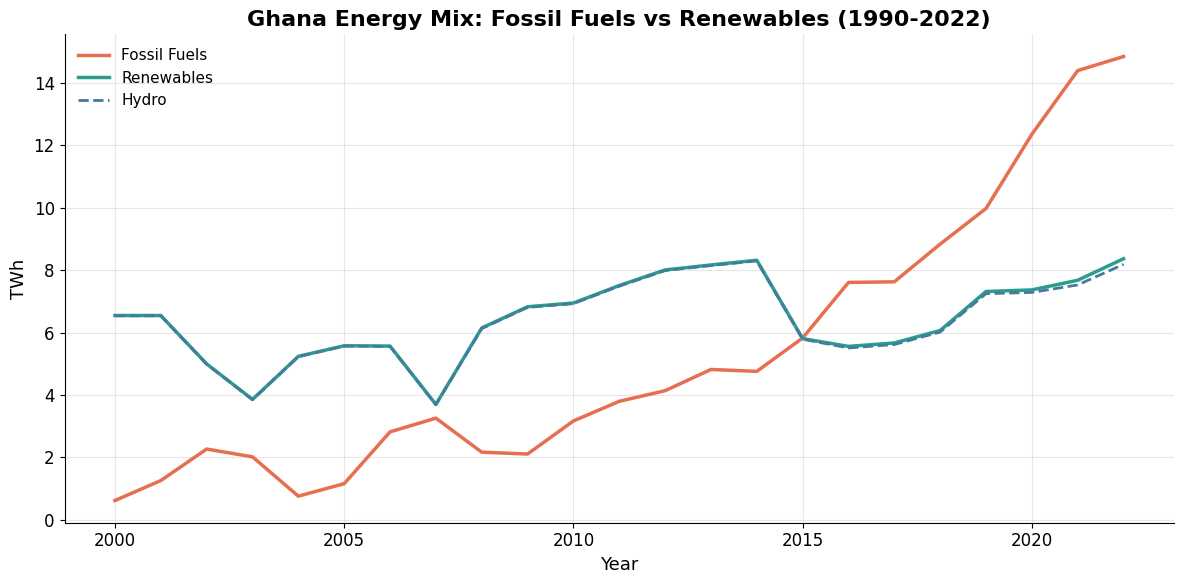

In [9]:
ghana = df_clean[df_clean['country'] == 'Ghana'].copy()

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(ghana['year'], ghana['fossil_electricity'], color='#E76F51', linewidth=2.5, label='Fossil Fuels')
ax.plot(ghana['year'], ghana['renewables_electricity'], color='#2A9D8F', linewidth=2.5, label='Renewables')
ax.plot(ghana['year'], ghana['hydro_electricity'], color='#457B9D', linewidth=2, linestyle='--', label='Hydro')

ax.set_title("Ghana Energy Mix: Fossil Fuels vs Renewables (1990-2022)")
ax.set_xlabel('Year')
ax.set_ylabel('TWh')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

1. ** Renewables Growth**: Average renewable electricity generation across Africa nearly tripled from 3 TWh to 9 TWh between 1990 and 2022, with the sharpest acceleration post -2010.
2. **Country Leaders**: Ethiopia and Morocco lead Africa's renewable transition. Ethiopia through large hydro projects, Morocco through major solar investments.
3. **Fossils vs Renewables Gap**: Despite renewable growth, fossil fuel still dominate Africa's electricity mix. The gap is narrowing but remains large.
4. **Ghana Case Study**: Ghana shifted from hydro dependency to fossil fuel dominance between 2015 and 2022, driven by gas and oil power plant expansion. Renewable adoption remains critically low.

###Data Source
Our World in Data (OWID) Energy Dataset
20 African Countries, 1990-2022,
660 observations